In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
geolocations = pd.read_csv("../data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

In [6]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
order_payments (103886, 5)
order_reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)


### Distribuição da avaliações

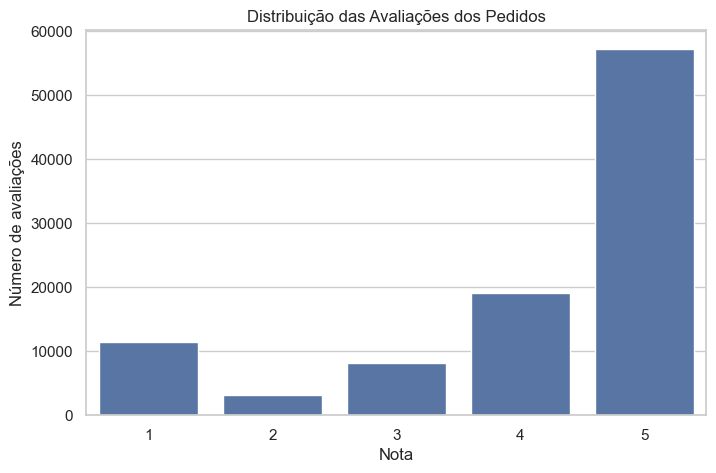

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=order_reviews,
    x="review_score",
    order=sorted(order_reviews["review_score"].unique())
)

plt.title("Distribuição das Avaliações dos Pedidos")
plt.xlabel("Nota")
plt.ylabel("Número de avaliações")

plt.show()

In [47]:
import duckdb

query = """
SELECT
    oi.seller_id,
    COUNT(DISTINCT oi.order_id) AS num_pedidos,
    AVG(orv.review_score) AS avg_review
FROM order_reviews orv
JOIN order_items oi
ON orv.order_id = oi.order_id
GROUP BY oi.seller_id
ORDER BY avg_review DESC

"""

resultado = duckdb.query(query).to_df()

resultado

,seller_id,num_pedidos,avg_review
0,2f3d8b4c9e2ee165075331fea3f3095a,1,5.0
1,5de1c80811ce7007f62f00d971236c09,2,5.0
2,0ade5cc4a305ed7093a23f68ca47519c,2,5.0
3,1de62b6f2fd96227629786db492433db,2,5.0
4,6a3139c7bf09ece22a4713d956acbe5e,1,5.0
...,...,...,...
3085,c85d7b477a709c85a1e8b8f25aa1b270,1,1.0
3086,4be2e7f96b4fd749d52dff41f80e39dd,1,1.0
3087,a0e19590a0923cdd0614ea9427713ced,2,1.0
3088,f0563bacf40c311f1c4d3d6b67b8a7a7,1,1.0


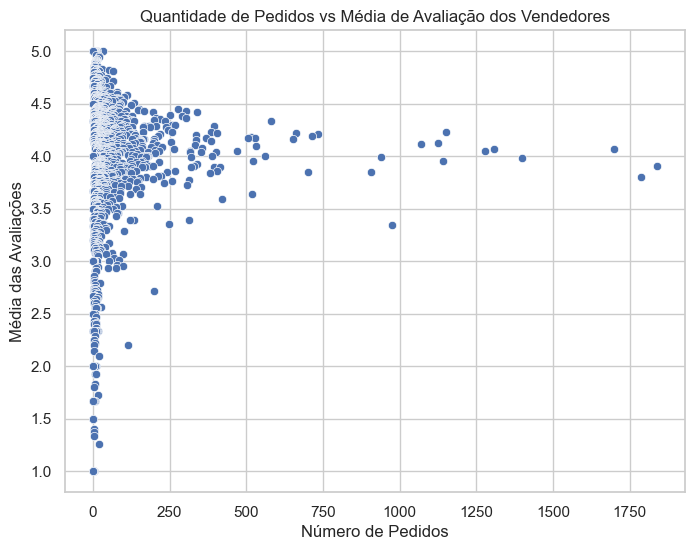

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=resultado,
    x="num_pedidos",
    y="avg_review"
)

plt.title("Quantidade de Pedidos vs Média de Avaliação dos Vendedores")
plt.xlabel("Número de Pedidos")
plt.ylabel("Média das Avaliações")

plt.show()

### Análise do tempo de Entrega dos Pedidos

In [ ]:
# Calcular tempo de entrega
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

## Junção de Tempo de Entrega, Avaliação Média e Volume de Pedidos

In [70]:
query_delivery = """
SELECT
    oi.seller_id,
    AVG(o.delivery_time_days) AS avg_delivery_time,
    COUNT(DISTINCT oi.order_id) AS num_pedidos,
    AVG(orv.review_score) AS avg_review

FROM orders o
JOIN order_items oi 
    ON o.order_id = oi.order_id

LEFT JOIN order_reviews orv
    ON o.order_id = orv.order_id

WHERE o.delivery_time_days IS NOT NULL 
  AND o.delivery_time_days > 0

GROUP BY oi.seller_id

HAVING COUNT(DISTINCT oi.order_id) >= 10

ORDER BY avg_delivery_time ASC
"""

top_sellers_delivery = duckdb.query(query_delivery).to_df()
 

In [72]:
bins = [0, 1, 2, 3, 4, 5]
labels = [
    "muito ruim",
    "ruim",
    "ok",
    "bom",
    "excelente"
]

top_sellers_delivery["review_categoria"] = pd.cut(
    top_sellers_delivery["avg_review"],
    bins=bins,
    labels=labels
)

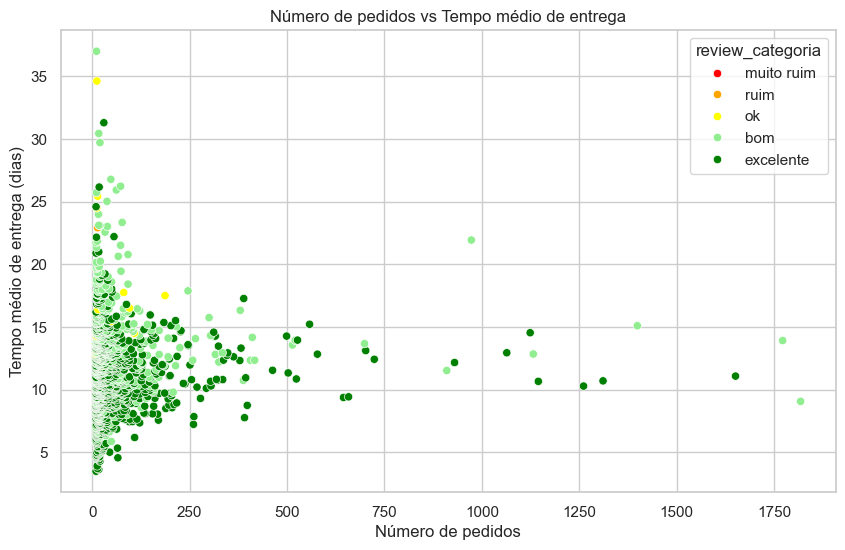

In [75]:
#import seaborn as sns
#import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

cores = [
    "red",
    "orange",
    "yellow",
    "lightgreen",
    "green"
]

sns.scatterplot(
    data=top_sellers_delivery,
    x="num_pedidos",
    y="avg_delivery_time",
    hue="review_categoria",
    palette=cores
)

plt.title("Número de pedidos vs Tempo médio de entrega")
plt.xlabel("Número de pedidos")
plt.ylabel("Tempo médio de entrega (dias)")

plt.show()